In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np
import torch

In [2]:
def time_matmul(type,x):
  """Returns the time required to do 10 matrix multiplications

  Parameters:
  type (string): The type of input matrix (x): 'Numpy' or Tensor (CPU or GPU)
  x (matrix): A square array to do matrix multiplication

  Returns:
  int: Time required to do 10 matrix multiplications
  """

  start = time.time()
  if type=='numpy':
    for loop in range(10):
      np.matmul(x,x)
  else:
    for loop in range(10):
      torch.matmul(x,x)
  return (time.time() - start)

In [6]:
shape_dim = []
numpy_time = []
cpu_tensor_time = []
gpu_tensor_time = []

for shape in range(500,3001,500):
  shape_dim.append(shape**2)

  # Create a numpy array of size [shape, shape] with elements sampled from
  # an uniform random ( over interval [0,1) ) distribution
  # Use function 'time_matmul' with type 'numpy' and append resulting time
  # to 'numpy_time'
  x_nump = np.random.rand(shape,shape)
  numpy_time.append(time_matmul('numpy',x_nump))

  # Your code goes here

  # Create a Tensor on CPU of size [shape, shape] with elements sampled from
  # an uniform random ( over interval [0,1) ) distribution
  # Use function 'time_matmul' with type 'cpu' and append resulting time
  # to 'cpu_tensor_time'
  x_cpu = torch.rand(shape,shape)
  cpu_tensor_time.append(time_matmul('cpu',x_cpu))

  # Your code goes here


  # Create a Tensor on GPU of size [shape, shape] with elements sampled from
  # an uniform random ( over interval [0,1) ) distribution
  # Use function 'time_matmul' with type 'gpu' and append resulting time
  # to 'gpu_tensor_time'
  x_gpu = torch.rand(shape,shape).cuda()
  gpu_tensor_time.append(time_matmul('gpu',x_gpu))

  # Your code goes here

In [7]:
numpy_time

[0.07023358345031738,
 0.5607936382293701,
 1.9045929908752441,
 4.7186174392700195,
 10.60574197769165,
 15.639043807983398]

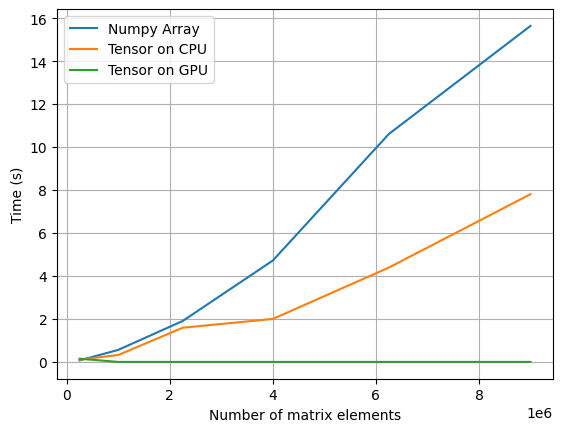

In [8]:
plt.figure()
plt.plot(shape_dim,numpy_time,label="Numpy Array")
plt.plot(shape_dim,cpu_tensor_time,label="Tensor on CPU")
plt.plot(shape_dim,gpu_tensor_time,label="Tensor on GPU")
plt.grid()
plt.xlabel("Number of matrix elements")
plt.ylabel("Time (s)")
plt.legend()
plt.show()